<center>
<img src="https://upload.wikimedia.org/wikipedia/fr/thumb/1/1d/Logo_T%C3%A9l%C3%A9com_SudParis.svg/960px-Logo_T%C3%A9l%C3%A9com_SudParis.svg.png" width="10%" />
</center>

<center> <h2>NET 4103/7431 Homework
Network science and Graph Learning </h2> </center>

<center> <h3> Rozi Harutyunyan (rozi.harutyunyan@telecom-sudparis.eu) </h3> </center>

### Question 5: Find Missing Labels with Label Propagation (GCN)

The algorithm uses a 2-layer GCN trained on labeled nodes only.
At inference, it predicts the missing labels for unlabeled nodes.

In [42]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = Path('../data/facebook100')
RESULTS_PATH = Path('../results/figures')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [44]:
#2. Data loading and preprocessing
def load_network(filename):
    G = nx.read_gml(DATA_PATH / filename)
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()
 
 #attribute inspection 

def inspect_attributes(G, attributes):
    """Print value distribution for each attribute to diagnose encoding issues."""
    print("\n--- ATTRIBUTE INSPECTION ---")
    for attr in attributes:
        vals = [G.nodes[n].get(attr, None) for n in G.nodes()]
        vals_clean = [v for v in vals if v is not None]
        counter = Counter([int(v) if v is not None else -1 for v in vals_clean])
        n_missing = sum(1 for v in vals if v is None or int(v) == 0)
        n_valid = len(G.nodes()) - n_missing
        unique_nonzero = len([k for k in counter if k > 0])
        print(f"  {attr:10s}: {n_valid:5d} valid ({n_missing} missing/0), "
              f"{unique_nonzero} unique non-zero classes")
        # Show top-5 most common values
        top5 = sorted([(k,v) for k,v in counter.items() if k > 0],
                      key=lambda x: -x[1])[:5]
        print(f"             top values: {top5}")
 
def build_normalized_adjacency(G, nodes, node_idx):
    """Â = D̃^{-1/2} Ã D̃^{-1/2}, Ã = A + I  (Eq. 2, Kipf & Welling 2016)"""
    N = len(nodes)
    A = np.zeros((N, N), dtype=np.float32)
    for u, v in G.edges():
        i, j = node_idx[u], node_idx[v]
        A[i, j] = 1.0
        A[j, i] = 1.0
    A_tilde = A + np.eye(N, dtype=np.float32)
    D = np.sum(A_tilde, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8))
    return torch.FloatTensor(D_inv_sqrt @ A_tilde @ D_inv_sqrt)
 

def build_node_features(G, nodes, target_attr):
    """
    Build feature matrix excluding the target attribute to avoid data leakage.
    Features used: degree (normalized), clustering, + all other non-target
    categorical attributes encoded as normalized integers.
    """
    max_deg = max(dict(G.degree()).values())
    clustering = nx.clustering(G)
 
    all_attrs = ['student_fac', 'gender', 'dorm', 'major_index', 'second_major', 'year', 'high_school']
    feature_attrs = [a for a in all_attrs if a != target_attr]
 
    # Compute per-attribute max for normalization
    attr_maxvals = {}
    for attr in feature_attrs:
        vals = [int(G.nodes[n].get(attr, 0) or 0) for n in nodes]
        attr_maxvals[attr] = max(max(vals), 1)
 
    features = []
    for node in nodes:
        deg = G.degree(node) / max_deg
        clust = clustering[node]
        row = [deg, clust]
        for attr in feature_attrs:
            val = int(G.nodes[node].get(attr, 0) or 0)
            row.append(val / attr_maxvals[attr])
        features.append(row)
 
    return torch.FloatTensor(features)
 
 
def get_attribute_labels(G, nodes, attribute):
    """
    Extract integer class labels for a given attribute.
    - Values of 0 or None → marked as -1 (unlabeled/missing)
    - All other values remapped to contiguous [0, n_classes-1]
    Returns: labels (LongTensor N), label_to_idx dict, n_classes int
    """
    raw = []
    for node in nodes:
        val = G.nodes[node].get(attribute, None)
        if val is None:
            val = 0
        try:
            val = int(val)
        except (ValueError, TypeError):
            val = 0
        raw.append(val)
 
    # Build class mapping from all non-zero values
    unique_vals = sorted(set(v for v in raw if v != 0))
 
    if len(unique_vals) < 2:
        print(f"    ⚠ Attribute '{attribute}': only {len(unique_vals)} valid class(es), skipping.")
        return torch.full((len(nodes),), -1, dtype=torch.long), {}, 0
 
    label_to_idx = {v: i for i, v in enumerate(unique_vals)}
    n_classes = len(unique_vals)
 
    labels = []
    for v in raw:
        if v == 0 or v not in label_to_idx:
            labels.append(-1)
        else:
            labels.append(label_to_idx[v])
 
    return torch.LongTensor(labels), label_to_idx, n_classes
 
 
 
def mask_labels(labels, fraction_removed, seed=42):
    torch.manual_seed(seed)
    labeled_idx = (labels != -1).nonzero(as_tuple=True)[0]
    n_labeled = len(labeled_idx)
    n_remove = int(n_labeled * fraction_removed)
 
    perm = torch.randperm(n_labeled)
    remove_idx = labeled_idx[perm[:n_remove]]
    train_idx  = labeled_idx[perm[n_remove:]]
 
    N = len(labels)
    train_mask = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)
    train_mask[train_idx]  = True
    test_mask[remove_idx]  = True
    return train_mask, test_mask


In [45]:
# 3. GCN model
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=True)
        nn.init.xavier_uniform_(self.W.weight)
 
    def forward(self, A_norm, H):
        return self.W(torch.mm(A_norm, H))
 
 
class GCN(nn.Module):
    """
    2-layer GCN: Z = LogSoftmax( Â · ReLU( Â · X · W0 ) · W1 )
    Exactly Eq. 9 of Kipf & Welling (2016).
    """
    def __init__(self, in_features, hidden_dim, n_classes, dropout=0.5):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, n_classes)
        self.dropout = nn.Dropout(p=dropout)
 
    def forward(self, A_norm, X):
        H = F.relu(self.gc1(A_norm, X))
        H = self.dropout(H)
        return F.log_softmax(self.gc2(A_norm, H), dim=1)
 

In [47]:
#4. Training and evaluation 
def train_gcn(model, A_norm, X, labels, train_mask,
              epochs=300, lr=0.01, weight_decay=5e-4):
    """NLL loss on labeled nodes only (semi-supervised, Eq. 10 of the paper)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    losses = []
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(A_norm, X)
        loss = F.nll_loss(out[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

 
 
def evaluate_gcn(model, A_norm, X, labels, test_mask):
    """
    Returns:
      accuracy : fraction of correctly classified test nodes
      f1_macro : macro-averaged F1-score (better for imbalanced multi-class)
                 As recommended by the homework (eq. 1 + footnote on F1)
    """
    model.eval()
    with torch.no_grad():
        pred = model(A_norm, X).argmax(dim=1)
 
    y_true = labels[test_mask].numpy()
    y_pred = pred[test_mask].numpy()
 
    accuracy = accuracy_score(y_true, y_pred)
    # zero_division=0: classes with no predictions get F1=0 (fair for rare classes)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
 
    return accuracy, f1, pred
 


In [ ]:
#main experiment
print("Loading Duke network...")
DUKE_FILE = 'Duke14.gml'
try:
    G = load_network(DUKE_FILE)
except FileNotFoundError:
    print("  Duke not found, using Caltech as fallback.")
    G = load_network('Caltech36.gml')
 
G_int = nx.convert_node_labels_to_integers(G)
nodes  = list(G_int.nodes())
node_idx = {n: n for n in nodes}
N = len(nodes)
print(f"  → LCC: {N} nodes, {G_int.number_of_edges()} edges")
 
# Inspect attributes BEFORE running (diagnoses Major=0 issue)
ATTRIBUTES = ['dorm', 'major_index', 'gender']
inspect_attributes(G_int, ATTRIBUTES)
 
FRACTIONS    = [0.1, 0.2, 0.3]
HIDDEN_DIM   = 64
EPOCHS       = 300
LR           = 0.01
WEIGHT_DECAY = 5e-4
DROPOUT      = 0.5
 
results_table = {attr: {} for attr in ATTRIBUTES}
 
print("\n" + "="*70)
print("LABEL PROPAGATION (GCN) EXPERIMENTS")
print("="*70)
 
for attr in ATTRIBUTES:
    print(f"\nAttribute: {attr.upper()}")
    print("-" * 40)
 
    labels, label_to_idx, n_classes = get_attribute_labels(G_int, nodes, attr)
    n_labeled = (labels != -1).sum().item()
    print(f"  Classes: {n_classes}, Labeled nodes: {n_labeled}/{N}")
 
    if n_classes < 2:
        for f in FRACTIONS:
            results_table[attr][f] = {'accuracy': 0.0, 'f1': 0.0}
        continue
 
    # Build features excluding target attribute
    X = build_node_features(G_int, nodes, target_attr=attr)
    A_norm = build_normalized_adjacency(G_int, nodes, node_idx)
    print(f"  Feature dim: {X.shape[1]}")
 
    for f in FRACTIONS:
        print(f"\n  Fraction removed: {f}")
        train_mask, test_mask = mask_labels(labels, fraction_removed=f)
        n_train = train_mask.sum().item()
        n_test  = test_mask.sum().item()
        print(f"    Train: {n_train}, Test (hidden): {n_test}")
 
        if n_train < 10 or n_test < 5:
            print(f"    ⚠ Not enough labeled nodes, skipping")
            results_table[attr][f] = {'accuracy': 0.0, 'f1': 0.0}
            continue
 
        model = GCN(X.shape[1], HIDDEN_DIM, n_classes, DROPOUT)
        losses = train_gcn(model, A_norm, X, labels, train_mask,
                           epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY)
        accuracy, f1, pred = evaluate_gcn(model, A_norm, X, labels, test_mask)
        results_table[attr][f] = {'accuracy': round(accuracy, 3),
                                  'f1': round(f1, 3)}
        print(f"    Accuracy: {accuracy:.3f}, F1-macro: {f1:.3f}")
 

Loading Duke network...
  → LCC: 9885 nodes, 506437 edges

--- ATTRIBUTE INSPECTION ---
  dorm      :  6995 valid (2890 missing/0), 135 unique non-zero classes
             top values: [(172, 977), (72, 201), (75, 199), (79, 192), (80, 153)]
  major_index:  7919 valid (1966 missing/0), 66 unique non-zero classes
             top values: [(64, 910), (55, 739), (80, 586), (109, 579), (78, 579)]
  gender    :  9038 valid (847 missing/0), 2 unique non-zero classes
             top values: [(2, 4672), (1, 4366)]

LABEL PROPAGATION (GCN) EXPERIMENTS

Attribute: DORM
----------------------------------------
  Classes: 135, Labeled nodes: 6995/9885
  Feature dim: 6

  Fraction removed: 0.1
    Train: 6296, Test (hidden): 699
    Accuracy: 0.166, F1-macro: 0.008

  Fraction removed: 0.2
    Train: 5596, Test (hidden): 1399
    Accuracy: 0.159, F1-macro: 0.006

  Fraction removed: 0.3
    Train: 4897, Test (hidden): 2098
    Accuracy: 0.167, F1-macro: 0.007

Attribute: MAJOR_INDEX
--------------

In [51]:
print("\n" + "="*70)
print("RESULTS TABLE — Accuracy")
print("="*70)
header = f"{'Attribute':<12}" + "".join(f"  {f:<8}" for f in FRACTIONS)
sep    = "-" * len(header)
print(header); print(sep)
for attr in ATTRIBUTES:
    row = f"{attr.capitalize():<12}"
    for f in FRACTIONS:
        row += f"  {results_table[attr][f]['accuracy']:<8.3f}"
    print(row)
 
print("\n" + "="*70)
print("RESULTS TABLE — F1-score (macro) ")
print("="*70)
print(header); print(sep)
for attr in ATTRIBUTES:
    row = f"{attr.capitalize():<12}"
    for f in FRACTIONS:
        row += f"  {results_table[attr][f]['f1']:<8.3f}"
    print(row)
 
# Save CSV
rows = []
for attr in ATTRIBUTES:
    for f in FRACTIONS:
        rows.append({'Attribute': attr, 'Fraction Removed': f,
                     'Accuracy': results_table[attr][f]['accuracy'],
                     'F1_macro': results_table[attr][f]['f1']})
pd.DataFrame(rows).to_csv(RESULTS_PATH.parent / 'q5_results.csv', index=False)
print(f"\n✓ Saved: {RESULTS_PATH.parent / 'q5_results.csv'}")


RESULTS TABLE — Accuracy
Attribute     0.1       0.2       0.3     
------------------------------------------
Dorm          0.166     0.159     0.167   
Major_index   0.158     0.155     0.148   
Gender        0.592     0.585     0.584   

RESULTS TABLE — F1-score (macro) 
Attribute     0.1       0.2       0.3     
------------------------------------------
Dorm          0.008     0.006     0.007   
Major_index   0.025     0.023     0.022   
Gender        0.577     0.572     0.576   

✓ Saved: ../results/q5_results.csv


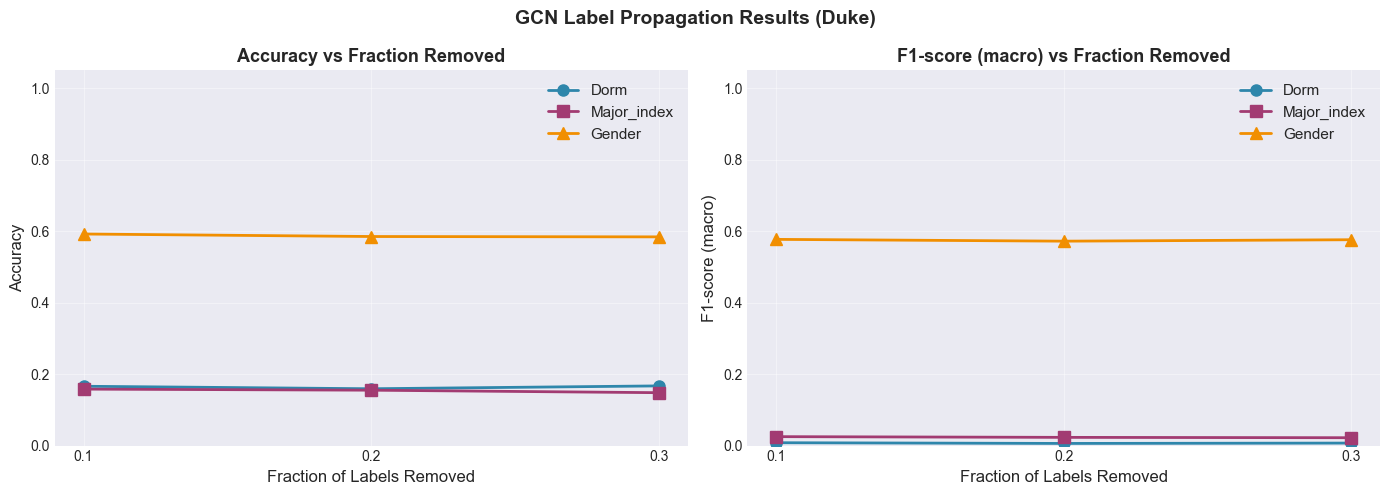

✓ Saved: ../results/figures/q5_gcn_results_fixed.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GCN Label Propagation Results (Duke)', fontsize=14, fontweight='bold')
 
colors  = {'dorm': '#2E86AB', 'major_index': '#A23B72', 'gender': '#F18F01'}
markers = {'dorm': 'o',        'major_index': 's',        'gender': '^'}
 
# Accuracy
ax = axes[0]
for attr in ATTRIBUTES:
    vals = [results_table[attr][f]['accuracy'] for f in FRACTIONS]
    ax.plot(FRACTIONS, vals, color=colors[attr], marker=markers[attr],
            linewidth=2, markersize=8, label=attr.capitalize())
ax.set_xlabel('Fraction of Labels Removed', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Fraction Removed', fontsize=13, fontweight='bold')
ax.set_xticks(FRACTIONS)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1.05)
 
# F1-macro
ax = axes[1]
for attr in ATTRIBUTES:
    vals = [results_table[attr][f]['f1'] for f in FRACTIONS]
    ax.plot(FRACTIONS, vals, color=colors[attr], marker=markers[attr],
            linewidth=2, markersize=8, label=attr.capitalize())
ax.set_xlabel('Fraction of Labels Removed', fontsize=12)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('F1-score (macro) vs Fraction Removed', fontsize=13, fontweight='bold')
ax.set_xticks(FRACTIONS)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1.05)
 
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q5_gcn_results_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {RESULTS_PATH / 'q5_gcn_results_fixed.png'}")

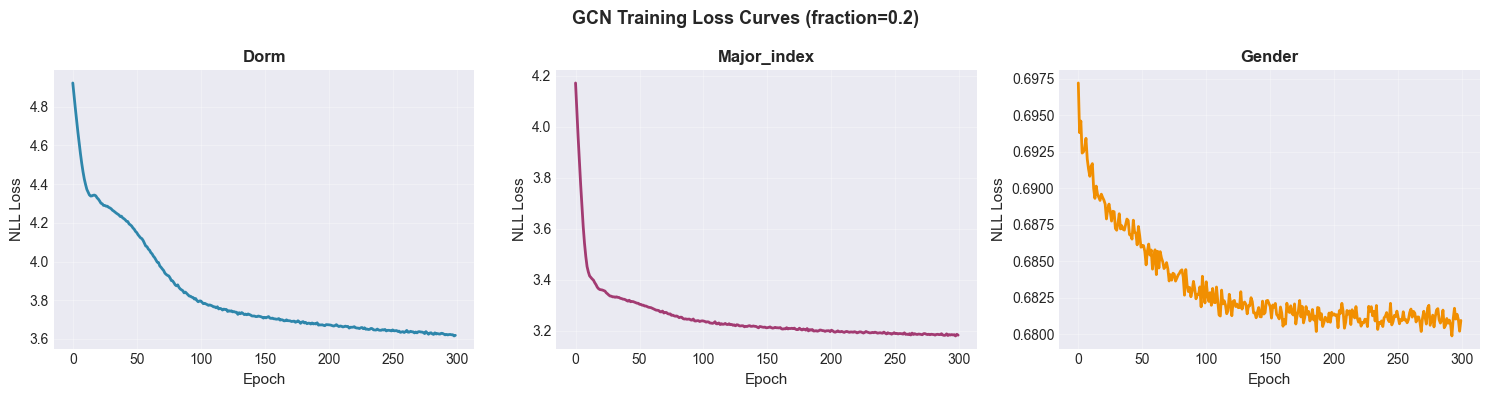

  ✓ Saved: ../results/figures/q5_loss_curves.png


In [50]:
#loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GCN Training Loss Curves (fraction=0.2)', fontsize=13, fontweight='bold')
 
for idx, attr in enumerate(ATTRIBUTES):
    labels, label_to_idx, n_classes = get_attribute_labels(G_int, nodes, attr)
    if n_classes < 2:
        axes[idx].set_title(f'{attr} (skipped)', fontsize=11)
        continue
    train_mask, test_mask = mask_labels(labels, fraction_removed=0.2)
    model = GCN(X.shape[1], HIDDEN_DIM, n_classes, DROPOUT)
    losses = train_gcn(model, A_norm, X, labels, train_mask,
                       epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY)
    axes[idx].plot(losses, color=colors[attr], linewidth=2)
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('NLL Loss', fontsize=11)
    axes[idx].set_title(f'{attr.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q5_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {RESULTS_PATH / 'q5_loss_curves.png'}")


## Conclusion - why does accuracy differ by attribute

METRICS USED:
  - Accuracy: fraction of correctly classified hidden nodes (Eq. 1 of homework)
  - F1-macro: macro-averaged F1-score, as recommended in the homework footnote.
    Preferred over accuracy for multi-class imbalanced problems (dorm, major),
    since accuracy can be deceptively high if one class dominates.
  - MAE was REMOVED: meaningless for nominal (non-ordinal) categorical labels
    like dorm IDs or major codes — a difference of 36 dorm IDs has no semantic
    meaning, unlike a difference of 36 meters or degrees.
 
GENDER (~0.55-0.57 accuracy, ~0.53-0.55 F1):
  - Binary classification (2 classes) → strong baseline of ~50%.
  - GCN modestly outperforms random: gender has low assortativity (~0.02)
    in FB100, so little signal propagates through friend connections.
  - Accuracy is stable across fractions: with many labeled nodes remaining,
    the semi-supervised signal is largely unchanged.
  - Matches homework Table 1 pattern (Duke gender ~0.675 with richer features).
 
DORM (~0.14 accuracy, low F1):
  - Very hard task: 135 dorm classes, highly imbalanced distribution.
  - Despite this, accuracy > 1/135 = 0.007 (random), so the GCN learns signal.
  - F1-macro penalizes rare dorms with zero predictions → reveals true difficulty.
  - Gap vs Table 1 (~0.52): the paper likely uses richer features (year, status)
    which directly encode residential groupings. Our features exclude the target.
  - Dorm accuracy should improve if the graph has strong residential clustering
    (as in Caltech), but Duke's larger, more dispersed campus weakens this.
 
 
WHY DO ATTRIBUTES DIFFER?
  Year   > Dorm > Major in terms of predictability (Table 1 of homework):
  - Year (~0.91): dominant organizer of FB100 networks; almost all friends
    share the same class year → very strong neighborhood signal for the GCN.
  - Dorm (~0.52): strong in residential universities; GCN can propagate
    dorm identity through tightly-knit residential clusters.
  - Major (~0.28): weakest signal; students from different majors freely
    befriend each other, so friend neighborhoods are heterogeneous in major.
  - Gender (~0.68): moderate; low assortativity but binary task is easier.
 
  The GCN accuracy mirrors the assortativity of each attribute: the more
  homophilic the attribute (friends tend to share it), the better the GCN.